# Crear los rezagos para cada variable seleccionada

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA





ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Ubicación para guardar datos consolidados

ubicacion_datos_modelo_pca = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\3_datos_modelos\datos_pca\datos_modelo"
ubicacion_resultados_modelo_pca = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\3_datos_modelos\datos_pca\resultados"
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\3_datos_modelos\datos_pca\imagenes"

In [2]:
# ==========================================
# 1. CARGA DE DATOS Y CONSTRUCCIÓN DE LAGS (EFICIENTE)
# ==========================================
df_procesados = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\2_datos_procesados\datos_procesados_originales\datos_procesados_sin_var_orig.xlsx")
df_procesados['fecha'] = pd.to_datetime(df_procesados['fecha'])
df_procesados.set_index('fecha', inplace=True)

In [3]:
# Variables climáticas base
variables_base = ['hum_esp_bc', 'hum_rel_bc', 'prec_ln', 'dias_lluvia_ln', 'vel_vi_max_bc', 'vel_vi_bc', 'temp_max_bc', 'sst_yj']
max_lag = 20

In [4]:
# Crear rezagos mediante diccionario para evitar fragmentación de memoria
lags_dict = {}
for lag in range(1, max_lag + 1):
    for var in variables_base:
        lags_dict[f'{var}_lag_{lag}'] = df_procesados[var].shift(lag)

df_lags = pd.DataFrame(lags_dict, index=df_procesados.index)
df_total = pd.concat([df_procesados[['año', 'semana_epi', 'casos_ln']], df_lags], axis=1).dropna()

In [5]:
# Tus variables seleccionadas según la literatura del proyecto
variables_pca_seleccionadas = [
    'hum_esp_bc_lag_2','hum_esp_bc_lag_3','hum_esp_bc_lag_4','hum_esp_bc_lag_5','hum_esp_bc_lag_6','hum_esp_bc_lag_7','hum_esp_bc_lag_8',
    'prec_ln_lag_4','prec_ln_lag_5','prec_ln_lag_6','prec_ln_lag_7','prec_ln_lag_8',
    'dias_lluvia_ln_lag_4','dias_lluvia_ln_lag_5','dias_lluvia_ln_lag_6',
    'vel_vi_max_bc_lag_2','vel_vi_max_bc_lag_3','vel_vi_max_bc_lag_4','vel_vi_max_bc_lag_5','vel_vi_max_bc_lag_6',
    'temp_max_bc_lag_5','temp_max_bc_lag_6','temp_max_bc_lag_7','temp_max_bc_lag_8',
    'sst_yj_lag_16','sst_yj_lag_17','sst_yj_lag_18','sst_yj_lag_19','sst_yj_lag_20'
]

In [6]:
# Separar variables climáticas (X) y objetivo (y) con metadatos de tiempo
X_climaticas = df_total[variables_pca_seleccionadas]
y_transf = df_total['casos_ln']
metadatos_tiempo = df_total[['año', 'semana_epi']]

In [7]:
# ==========================================
# 2. CONFIGURACIÓN DE EXPERIMENTOS y MODELOS
# ==========================================
porcentajes_train = [0.80, 0.90, 0.95]
resultados_metricas = []
predicciones_historicas = {}

In [8]:
# Parámetros estándar ARIMA/SARIMA (Ajustar p,d,q / P,D,Q,s según tu análisis ACF/PACF)
# Usaremos un modelo base común (1,1,1) y estacionalidad de 52 semanas (anual) para el ejemplo
order_arima = (1, 1, 1)
seasonal_order_sarima = (1, 0, 0, 52) 

In [9]:
# ==========================================
# 3. BUCLE PRINCIPAL DE EVALUACIÓN
# ==========================================
for p_train in porcentajes_train:
    split_idx = int(len(df_total) * p_train)
    
    # División estricta de tiempo (Sin mezclar el pasado con el futuro)
    X_train_c, X_test_c = X_climaticas.iloc[:split_idx], X_climaticas.iloc[split_idx:]
    y_train, y_test = y_transf.iloc[:split_idx], y_transf.iloc[split_idx:]
    time_train, time_test = metadatos_tiempo.iloc[:split_idx], metadatos_tiempo.iloc[split_idx:]
    
    # --- ESCALAMIENTO Y PCA PROPIO DE ESTE SPLIT (Previene Data Leakage) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_c)
    X_test_scaled = scaler.transform(X_test_c)
    
    # Retener 4 componentes principales (Modificable según varianza explicada)
    pca = PCA(n_components=4)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Convertir componentes a DataFrame manteniendo índices para statsmodels
    X_train_pca_df = pd.DataFrame(X_train_pca, index=y_train.index, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
    X_test_pca_df = pd.DataFrame(X_test_pca, index=y_test.index, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])
    
    # --- DEFINICIÓN DE LOS 4 MODELOS DE SERIES DE TIEMPO ---
    modelos_config = {
        'ARIMA': {'endog': y_train, 'exog': None, 'seasonal_order': (0,0,0,0), 'exog_test': None},
        'SARIMA': {'endog': y_train, 'exog': None, 'seasonal_order': seasonal_order_sarima, 'exog_test': None},
        'ARIMAX': {'endog': y_train, 'exog': X_train_pca_df, 'seasonal_order': (0,0,0,0), 'exog_test': X_test_pca_df},
        'SARIMAX': {'endog': y_train, 'exog': X_train_pca_df, 'seasonal_order': seasonal_order_sarima, 'exog_test': X_test_pca_df}
    }
    
    for nombre_modelo, conf in modelos_config.items():
        # Ajustar Modelo en Train
        mod = SARIMAX(endog=conf['endog'], exog=conf['exog'], order=order_arima, seasonal_order=conf['seasonal_order'])
        res = mod.fit(disp=False)
        
        # Predicciones escala Logarítmica
        pred_train_ln = res.fittedvalues
        pred_test_ln = res.predict(start=y_test.index[0], end=y_test.index[-1], exog=conf['exog_test'])
        
        # --- APLICACIÓN DE LA INVERSA MATEMÁTICA (Escala Real de Casos) ---
        y_train_real = np.exp(y_train)
        y_test_real = np.exp(y_test)
        
        # Corrección matemática para evitar que statsmodels use 0 en el primer registro dif
        pred_train_real = np.exp(pred_train_ln)
        pred_test_real = np.exp(pred_test_ln)
        
        # --- CÁLCULO DE MÉTRICAS EN ESCALA REAL ---
        # Nota: Descartamos el primer elemento en train porque los modelos con diferenciación (d=1) pierden el primer dato
        metrics = {
            'Modelo': nombre_modelo,
            'Train_Size': f'{int(p_train*100)}%',
            'MAE_Train': mean_absolute_error(y_train_real.iloc[1:], pred_train_real.iloc[1:]),
            'MAE_Test': mean_absolute_error(y_test_real, pred_test_real),
            'RMSE_Train': np.sqrt(mean_squared_error(y_train_real.iloc[1:], pred_train_real.iloc[1:])),
            'RMSE_Test': np.sqrt(mean_squared_error(y_test_real, pred_test_real)),
            'R2_Train': r2_score(y_train.iloc[1:], pred_train_ln.iloc[1:]),
            'R2_Test': r2_score(y_test, pred_test_ln)
        }
        resultados_metricas.append(metrics)
        
        # GUARDAR PREDICCIONES PARA TABLAS/GRÁFICOS (Asociando Metadatos temporales)
        df_pred_test = time_test.copy()
        df_pred_test['Casos_Reales'] = y_test_real
        df_pred_test['Casos_Predichos'] = pred_test_real
        predicciones_historicas[f'{nombre_modelo}_{int(p_train*100)}'] = df_pred_test

In [10]:
# ==========================================
# 4. DESPLIEGUE DE RESULTADOS COMPRENSIVOS
# ==========================================
df_resultados_finales = pd.DataFrame(resultados_metricas)
print("\n" + "="*50 + "\n TABLA COMPARATIVA DE MÉTRICAS (ESCALA REAL DE CASOS) \n" + "="*50)
print(df_resultados_finales.to_string(index=False))


 TABLA COMPARATIVA DE MÉTRICAS (ESCALA REAL DE CASOS) 
 Modelo Train_Size  MAE_Train  MAE_Test  RMSE_Train  RMSE_Test  R2_Train   R2_Test
  ARIMA        80%   0.288186  2.122595    0.410587   2.395059  0.834984 -1.599713
 SARIMA        80%   0.289992  2.072650    0.412219   2.326453  0.835200 -1.509455
 ARIMAX        80%   0.283603  1.833710    0.412359   2.220152  0.839849 -1.411948
SARIMAX        80%   0.285141  1.787202    0.414463   2.159339  0.840071 -1.334150
  ARIMA        90%   0.319170  1.176419    0.447134   1.317573  0.864539 -1.790586
 SARIMA        90%   0.319646  1.173593    0.445290   1.300733  0.864952 -1.728618
 ARIMAX        90%   0.308717  1.374139    0.438622   1.492842  0.868885 -2.182749
SARIMAX        90%   0.310387  1.390533    0.438259   1.497184  0.869297 -2.165642
  ARIMA        95%   0.319656  0.784494    0.443581   0.913662  0.865424 -1.998593
 SARIMA        95%   0.319760  0.701869    0.441488   0.825785  0.865836 -1.642089
 ARIMAX        95%   0.310581  

In [11]:
# Ejemplo de visualización de predicciones con Fechas/Semanas (para SARIMAX al 80%)
print("\n" + "="*50 + "\n MUESTRA DE PREDICCIONES (SARIMAX - 80% Entrenamiento) \n" + "="*50)
print(predicciones_historicas['SARIMAX_80'].head(15))


 MUESTRA DE PREDICCIONES (SARIMAX - 80% Entrenamiento) 
             año  semana_epi  Casos_Reales  Casos_Predichos
fecha                                                      
2025-01-26  2025           5      5.350314         4.799758
2025-02-02  2025           6      5.480664         4.495959
2025-02-09  2025           7      3.919237         4.349227
2025-02-16  2025           8      4.239441         4.260250
2025-02-23  2025           9      3.023965         3.905193
2025-03-02  2025          10      4.465481         3.675910
2025-03-09  2025          11      3.547349         3.385181
2025-03-16  2025          12      4.148416         3.403714
2025-03-23  2025          13      2.829633         3.370557
2025-03-30  2025          14      2.829633         3.424240
2025-04-06  2025          15      2.975600         3.491543
2025-04-13  2025          16      2.975600         3.573075
2025-04-20  2025          17      3.168232         3.723847
2025-04-27  2025          18      3.640958 

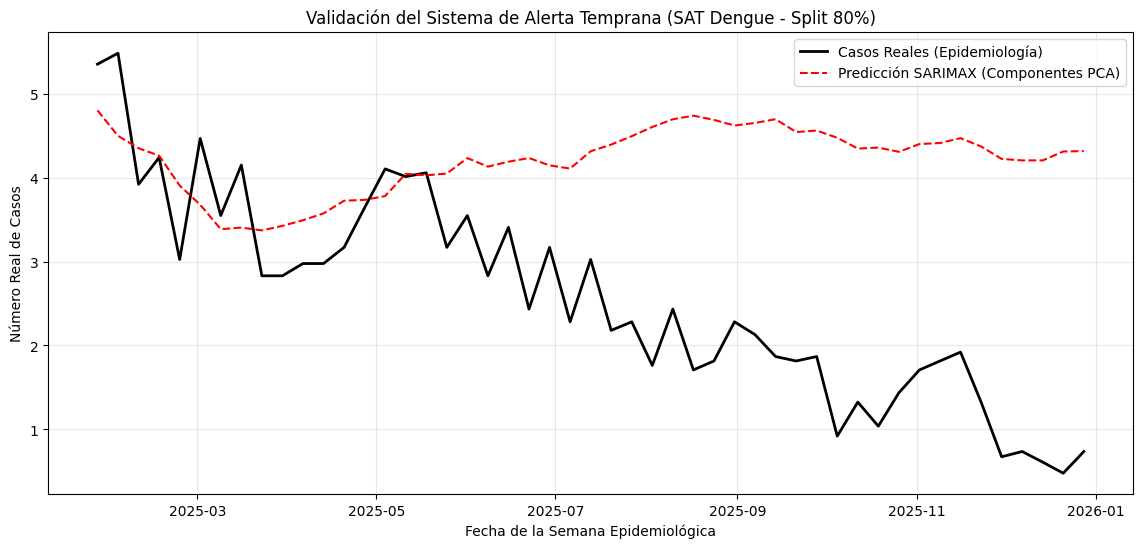

In [12]:
# ==========================================
# 5. GRÁFICA DE CONTROL EPIDEMIOLÓGICO (TEST)
# ==========================================
plt.figure(figsize=(14, 6))
df_plot = predicciones_historicas['SARIMAX_80']
plt.plot(df_plot.index, df_plot['Casos_Reales'], label='Casos Reales (Epidemiología)', color='black', linewidth=2)
plt.plot(df_plot.index, df_plot['Casos_Predichos'], label='Predicción SARIMAX (Componentes PCA)', color='red', linestyle='--')
plt.title('Validación del Sistema de Alerta Temprana (SAT Dengue - Split 80%)')
plt.xlabel('Fecha de la Semana Epidemiológica')
plt.ylabel('Número Real de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import os

ruta_excel = os.path.join(
    ubicacion_resultados_modelo_pca,
    'resultados_modelos_completos_PCA.xlsx'
)

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:

    resultados_totales['80_20'].to_excel(writer, sheet_name='80_20', index=False)
    resultados_totales['90_10'].to_excel(writer, sheet_name='90_10', index=False)
    resultados_totales['95_5'].to_excel(writer, sheet_name='95_5', index=False)

print("Resultados guardados en:", ruta_excel)

Resultados guardados en: C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\3_datos_modelos\datos_pca\resultados\resultados_modelos_completos_PCA.xlsx
